In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Loading the dataset of the players from the top 5 European leagues for the season 2025-2026
dataset=pd.read_csv('players_data-2025_2026.csv')
print('Whole dataset:')
dataset.set_index('Rk', inplace=True)
print(dataset.head(50))

Whole dataset:
                 Player   Nation    Pos              Squad  \
Rk                                                           
1      Brenden Aaronson   us USA  MF,FW       Leeds United   
2           Zach Abbott  eng ENG     DF  Nottingham Forest   
3   Jones El-Abdellaoui   ma MAR  MF,FW         Celta Vigo   
4         Himad Abdelli   dz ALG  FW,MF          Marseille   
5         Himad Abdelli   dz ALG     MF             Angers   
6              Ali Abdi   tn TUN  DF,MF               Nice   
7     Salis Abdul Samed   gh GHA     MF               Nice   
8       Saud Abdulhamid   sa KSA     MF               Lens   
9              Tay Abed   il ISR     MF            Levante   
10      Laurent Abergel   fr FRA     MF            Lorient   
11       Matthis Abline   fr FRA  FW,MF             Nantes   
12                Abner   br BRA  DF,MF               Lyon   
13    Zakaria Aboukhlal   ma MAR     MF             Torino   
14          Abdel Abqar   ma MAR     DF             Get

In [3]:
# partitioning the dataset into goalkeepers and outfield players
gk=dataset[dataset['Pos'].isin(['GK'])]

In [4]:
gk.isna().sum().sort_values(ascending=False).head(20)

G/SoT       169
SoT%        164
G/Sh        164
Mn/Sub      147
On-Off       34
Mn/Start      3
CS%           3
Save%         1
Comp          0
Min           0
90s           0
Gls           0
Starts        0
G+A           0
Age           0
MP            0
Born          0
CrdY          0
CrdR          0
G+A-PK        0
dtype: int64

In [5]:
gk

,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
Rk,,,,,,,,,,,,,,,,,,,,,
39,Julen Agirrezabala,es ESP,GK,Valencia,es La Liga,25.0,2000.0,18,18,1620,...,1,0,0,0,1,0,0,0,1,0
79,Alisson,br BRA,GK,Liverpool,eng Premier League,33.0,1992.0,25,25,2250,...,1,0,0,1,7,0,0,0,0,0
109,Nícolas Andrade,br BRA,GK,Pisa,it Serie A,37.0,1988.0,5,5,450,...,0,0,0,0,1,0,0,0,0,0
136,Alphonse Areola,fr FRA,GK,West Ham United,eng Premier League,33.0,1993.0,20,20,1800,...,0,0,0,1,1,0,0,1,0,0
139,Paul Argney,fr FRA,GK,Le Havre,fr Ligue 1,19.0,2006.0,1,1,90,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2594,Guglielmo Vicario,it ITA,GK,Tottenham Hotspur,eng Premier League,29.0,1996.0,30,30,2700,...,1,0,0,0,3,0,0,0,1,0
2608,Odysseas Vlachodimos,gr GRE,GK,Sevilla,es La Liga,31.0,1994.0,24,24,2160,...,1,0,0,0,0,0,0,1,0,0
2699,Robin Zentner,de GER,GK,Mainz 05,de Bundesliga,31.0,1994.0,9,9,786,...,2,1,0,2,1,0,0,0,0,0


In [6]:
keeper_columns = [
    'Rk_stats_keeper', 'Nation_stats_keeper', 'Pos_stats_keeper', 
    'Comp_stats_keeper', 'Age_stats_keeper', 'Born_stats_keeper', 
    'MP_stats_keeper', 'Starts_stats_keeper', 'Min_stats_keeper', 
    '90s_stats_keeper', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 
    'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 
    'PKA', 'PKsv', 'PKm']

In [7]:
Outfield=dataset[dataset['Pos'].isin(['DF', 'MF', 'FW'])]
Outfield.drop(columns=keeper_columns, inplace=True)
print('Outfield dataset:')
Outfield

Outfield dataset:


C:\Users\franc\AppData\Local\Temp\ipykernel_10216\3625979237.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Outfield.drop(columns=keeper_columns, inplace=True)


,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
Rk,,,,,,,,,,,,,,,,,,,,,
2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,2,1,120,...,0,0,0,2,1,0,3,2,2,0
5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,943,...,1,0,0,16,12,1,9,13,17,0
7,Salis Abdul Samed,gh GHA,MF,Nice,fr Ligue 1,25.0,2000.0,14,9,663,...,3,0,0,14,7,0,1,9,7,0
8,Saud Abdulhamid,sa KSA,MF,Lens,fr Ligue 1,26.0,1999.0,19,9,918,...,2,0,0,17,9,1,30,5,19,0
9,Tay Abed,il ISR,MF,Levante,es La Liga,22.0,2004.0,2,0,23,...,0,0,0,0,1,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2714,Martín Zubimendi,es ESP,MF,Arsenal,eng Premier League,27.0,1999.0,31,30,2596,...,4,0,0,27,10,0,12,35,31,0
2715,Martin Ødegaard,no NOR,MF,Arsenal,eng Premier League,27.0,1998.0,20,13,1076,...,0,0,0,7,7,2,20,7,7,0
2716,Luka Đurić,rs SRB,MF,Hoffenheim,de Bundesliga,22.0,2003.0,1,0,10,...,0,0,0,0,0,0,0,0,0,0


In [9]:
#group outfield players by goals (Gls)
Outfield.groupby('Gls')['Player'].count().sort_values(ascending=False).head(20)

Gls
0     1072
1      415
2      183
3       97
4       54
5       48
7       27
8       21
6       20
10      12
9       11
11       5
12       3
13       2
14       2
15       2
18       1
19       1
22       1
23       1
Name: Player, dtype: int64

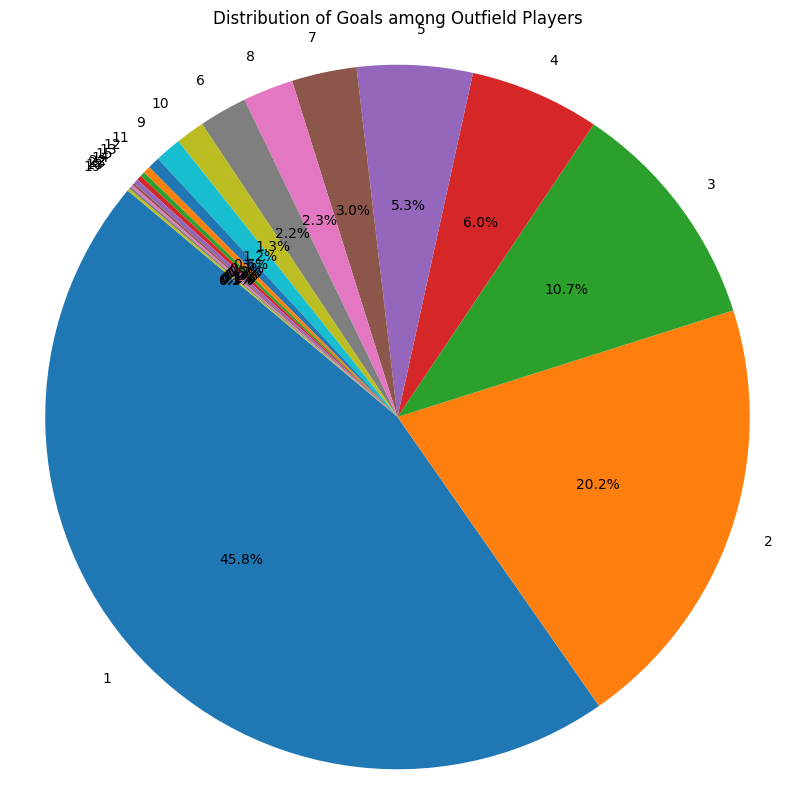

In [13]:
#pie distribution visualization of the distribution of goals among outfield players
# Filter for players with at least 1 goal
scorers = Outfield[Outfield['Gls'] > 0]

# Now run your pie chart code on the 'scorers' dataframe
labels = scorers['Gls'].value_counts().index
sizes = scorers['Gls'].value_counts().values

plt.figure(figsize=(10,10))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Distribution of Goals among Outfield Players')
plt.show()


In [10]:
#gourp outfield players by assists (Ast)
Outfield.groupby('Ast')['Player'].count().sort_values(ascending=False).head(20)

Ast
0     1176
1      404
2      180
3      109
4       62
5       18
6       11
7        7
8        6
11       1
12       1
13       1
16       1
17       1
Name: Player, dtype: int64